Kemenangan yang Mulai Retak

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ASEAN8 = ["Indonesia", "Vietnam", "Thailand", "Philippines",
          "Myanmar", "Cambodia", "Laos", "Malaysia"]
ASEAN7 = [c for c in ASEAN8 if c != "Laos"]
NAMA_ID = {"Indonesia": "Indonesia", "Vietnam": "Vietnam", "Thailand": "Thailand",
           "Philippines": "Filipina", "Myanmar": "Myanmar", "Cambodia": "Kamboja",
           "Malaysia": "Malaysia"}
WARNA_MEMBAIK, WARNA_REVERSAL = "#2E8B57", "#D64545"

UNDER_URL = "/content/prevalence-of-undernourishment.csv"

# fallback: seri penuh 2001-2023 (%), diambil dari OWID (FAO)
_years_fb = list(range(2001, 2024))
_under_fallback_data = {
    "Indonesia": [18.1,18.1,18.0,18.2,18.4,18.1,17.5,16.5,15.0,12.9,10.9,9.5,8.3,7.8,7.1,6.6,6.0,6.0,6.4,6.6,6.6,6.6,6.3],
    "Myanmar":   [38.6,35.8,32.6,28.8,24.8,21.0,17.4,14.0,11.1,9.2,8.0,7.4,6.4,5.5,4.5,3.8,3.5,3.4,3.2,3.7,4.4,5.2,5.4],
    "Cambodia":  [19.7,17.8,16.6,16.3,15.5,14.4,13.3,12.1,11.2,10.0,9.2,8.5,8.4,8.1,7.5,6.8,6.3,5.6,5.4,5.6,6.1,5.8,5.2],
    "Malaysia":  [2.5,2.8,2.9,3.1,3.2,3.4,3.6,3.6,3.8,3.5,3.4,3.5,3.7,3.8,3.7,3.3,3.1,2.9,2.8,2.7,2.5,2.5,2.5],
    "Vietnam":   [19.5,17.7,16.0,15.3,15.2,14.9,13.8,12.5,11.3,10.4,9.3,8.8,8.4,8.3,8.0,7.7,7.3,6.9,6.4,5.9,5.6,5.4,5.3],
    "Thailand":  [17.3,16.3,14.9,13.6,11.8,10.6,10.1,10.6,10.4,10.2,9.4,9.3,8.7,8.2,7.8,7.9,8.1,7.6,6.8,6.0,5.4,5.1,4.6],
    "Philippines":[18.5,18.3,17.8,17.6,17.3,17.0,16.7,16.4,16.0,15.7,14.9,14.3,13.7,12.9,11.4,9.7,7.8,6.4,5.8,5.2,4.6,3.5,3.0],
}
_under_fallback = pd.DataFrame(_under_fallback_data, index=_years_fb).reset_index()
_under_fallback = _under_fallback.rename(columns={"index": "Year"}).melt(
    id_vars="Year", var_name="Entity", value_name="Value")

try:
    under_raw = pd.read_csv(UNDER_URL, storage_options={"User-Agent": "notebook/1.0"})
    print("[OK] Data diambil langsung dari OWID.")
except Exception as e:
    print(f"[INFO] Gagal akses OWID ({e}); pakai data cadangan.")
    under_raw = _under_fallback.copy()

under_raw.head()

[INFO] Gagal akses OWID (storage_options passed with file object or non-fsspec file path); pakai data cadangan.


,Year,Entity,Value
0,2001,Indonesia,18.1
1,2002,Indonesia,18.1
2,2003,Indonesia,18.0
3,2004,Indonesia,18.2
4,2005,Indonesia,18.4


In [2]:
value_col = [c for c in under_raw.columns if "undernour" in c.lower() or c == "Value"]
val_col = value_col[0] if value_col else "Value"

df_under = under_raw[under_raw["Entity"].isin(ASEAN7)][["Entity", "Year", val_col]]
df_under = df_under.rename(columns={val_col: "Value"}).dropna().sort_values(["Entity", "Year"])
asean_avg = df_under.groupby("Year")["Value"].mean().reset_index()

hasil = []
for neg in ASEAN7:
    sub = df_under[df_under["Entity"] == neg].sort_values("Year")
    tt_val, tt_thn = sub["Value"].min(), int(sub.loc[sub["Value"].idxmin(), "Year"])
    val_2022 = sub.loc[sub["Year"] == 2022, "Value"]
    val_2022 = float(val_2022.iloc[0]) if not val_2022.empty else np.nan
    sub_slope = sub[(sub["Year"] >= 2018) & (sub["Year"] <= 2022)]
    slope = stats.linregress(sub_slope["Year"], sub_slope["Value"]).slope if len(sub_slope) >= 2 else np.nan
    status = "REVERSAL" if (not np.isnan(slope) and slope > 0) else "membaik"
    hasil.append({"Negara": NAMA_ID[neg], "Entity": neg, "Titik_terendah_%": tt_val,
                  "Tahun_terendah": tt_thn, "Nilai_2022_%": val_2022,
                  "Slope_2018_2022_pp_per_thn": slope, "Status": status})

tabel_klaster = pd.DataFrame(hasil).sort_values("Slope_2018_2022_pp_per_thn", ascending=False)
tabel_klaster

,Negara,Entity,Titik_terendah_%,Tahun_terendah,Nilai_2022_%,Slope_2018_2022_pp_per_thn,Status
4,Myanmar,Myanmar,3.2,2019,5.2,0.48,REVERSAL
0,Indonesia,Indonesia,6.0,2017,6.6,0.14,REVERSAL
5,Kamboja,Cambodia,5.2,2023,5.8,0.11,REVERSAL
6,Malaysia,Malaysia,2.5,2001,2.5,-0.11,membaik
1,Vietnam,Vietnam,5.3,2023,5.4,-0.38,membaik
2,Thailand,Thailand,4.6,2023,5.1,-0.64,membaik
3,Filipina,Philippines,3.0,2023,3.5,-0.70,membaik


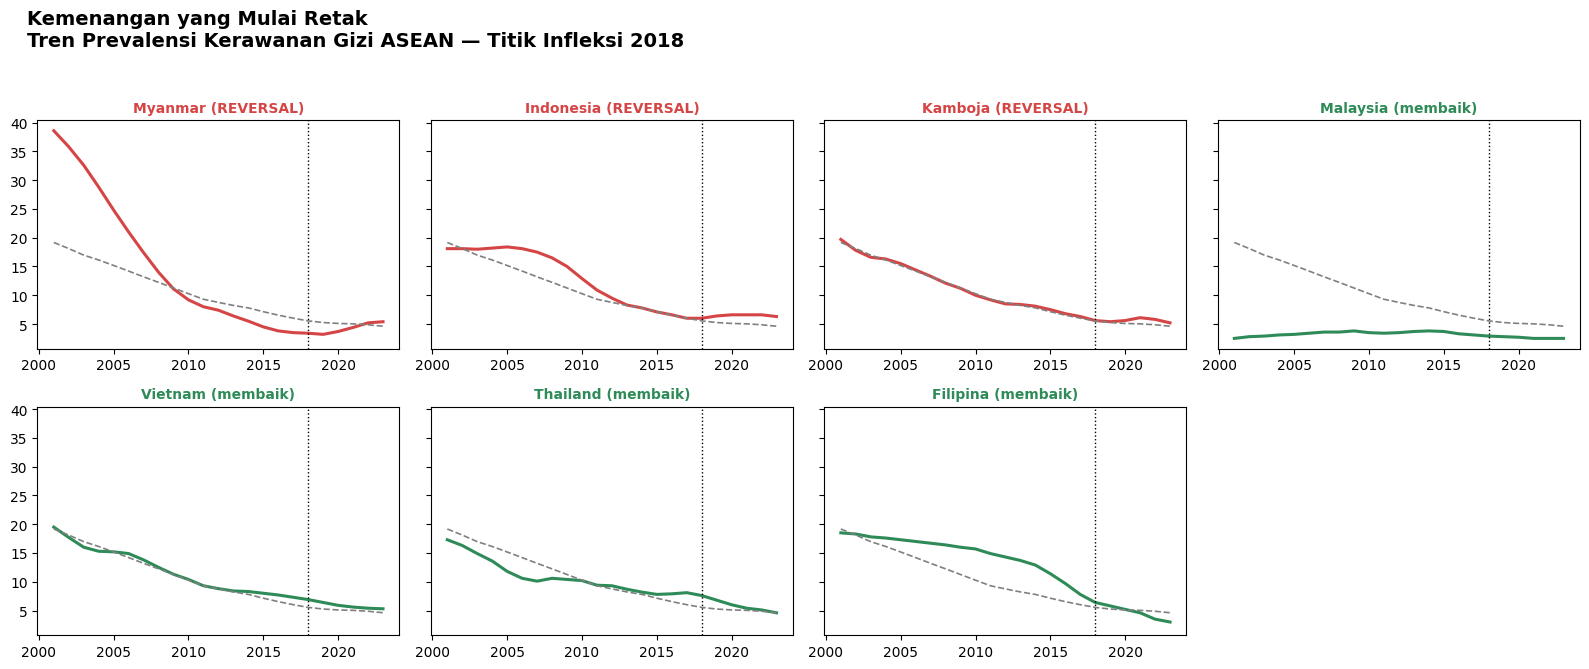

In [3]:
urutan = tabel_klaster.sort_values("Status")["Entity"].tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
axes = axes.flatten()

for i, neg in enumerate(urutan):
    ax = axes[i]
    sub = df_under[df_under["Entity"] == neg].sort_values("Year")
    status = tabel_klaster.loc[tabel_klaster["Entity"] == neg, "Status"].values[0]
    warna = WARNA_REVERSAL if status == "REVERSAL" else WARNA_MEMBAIK
    ax.plot(sub["Year"], sub["Value"], color=warna, linewidth=2.2)
    ax.plot(asean_avg["Year"], asean_avg["Value"], color="gray", linestyle="--", linewidth=1.2)
    ax.axvline(2018, color="black", linestyle=":", linewidth=1)
    ax.set_title(f"{NAMA_ID[neg]} ({status})", fontsize=10, fontweight="bold", color=warna)

for j in range(len(urutan), len(axes)):
    axes[j].axis("off")

fig.suptitle("Kemenangan yang Mulai Retak\nTren Prevalensi Kerawanan Gizi ASEAN — Titik Infleksi 2018",
             fontsize=14, fontweight="bold", x=0.02, ha="left")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()